In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("plots.mplstyle")

# Rabi oscillation simulation

Standard two-level Rabi formula: for a drive with Rabi frequency `rabi_freq` and detuning `delta_freq` from resonance (both regular frequencies, e.g. in MHz), the excited-state population, including phenomenological dephasing with time constant `T2*`, is

$$P(t) = \frac{1}{2}\frac{\nu_R^2}{\nu_R^2 + \delta^2} \left(1 - e^{-t/T_2^*}\cos\left(2\pi\sqrt{\nu_R^2 + \delta^2}\, t\right)\right)$$

which reduces to the undamped formula $P(t) = \frac{\nu_R^2}{\nu_R^2 + \delta^2}\sin^2\left(\pi\sqrt{\nu_R^2+\delta^2}\,t\right)$ as `T2* -> infinity`.

In [2]:
def rabi_population(t, rabi_freq, detuning_freq=0.0, t2_star=np.inf):
    """Excited-state population under Rabi driving. rabi_freq/detuning_freq
    are regular frequencies (e.g. MHz for t in us); t2_star is a time (e.g.
    us), with dephasing envelope exp(-t / t2_star)."""
    freq_eff = np.sqrt(rabi_freq**2 + detuning_freq**2)
    contrast = rabi_freq**2 / freq_eff**2
    decay = np.exp(-t / t2_star)
    return 0.5 * contrast * (1 - decay * np.cos(2 * np.pi * freq_eff * t))

## Try it

Set the three parameters below and run.

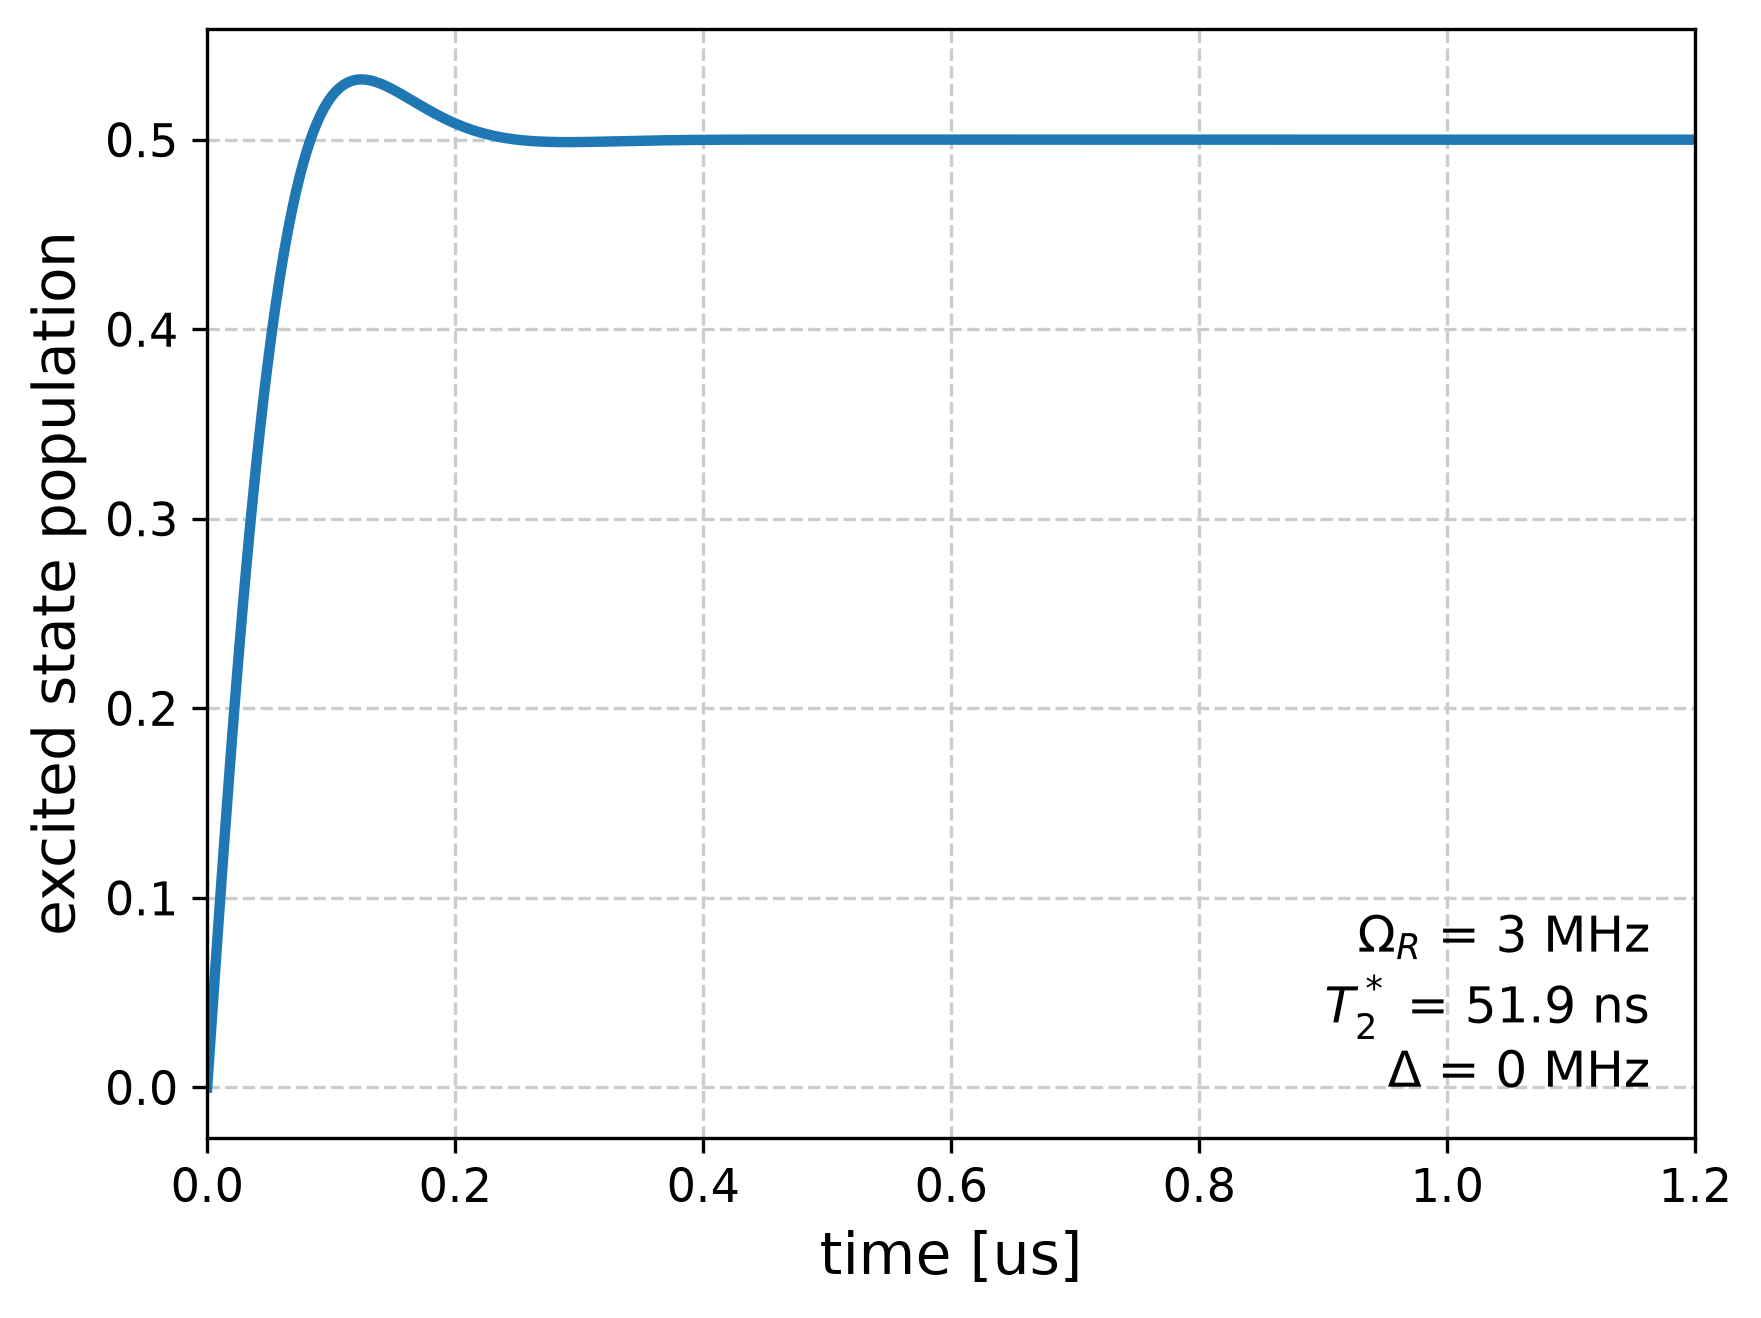

In [3]:
RABI_FREQ = 3  # MHz
DETUNING_FREQ = 0.0  # MHz, off-resonance amount
T2_STAR = 51.9e-3  # us, dephasing time (np.inf for no decay)

t_pi = 1 / (2 * RABI_FREQ)  # us
t = np.linspace(0, 10 * t_pi, 1000)
population = rabi_population(t, RABI_FREQ, detuning_freq=DETUNING_FREQ, t2_star=T2_STAR)

fig, ax = plt.subplots(dpi=300)
ax.plot(t, population)
ax.set_xlabel("time [us]")
ax.set_ylabel("excited state population")
ax.set_xlim([0, 1.2])
ax.text(
    0.97, 0.03,
    f"$\\Omega_R$ = {RABI_FREQ:g} MHz\n$T_2^*$ = {T2_STAR * 1000:g} ns\n$\\Delta$ = {DETUNING_FREQ:g} MHz",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
)
plt.show()

## Effect of detuning

Detuning both speeds up the oscillation and reduces its contrast.

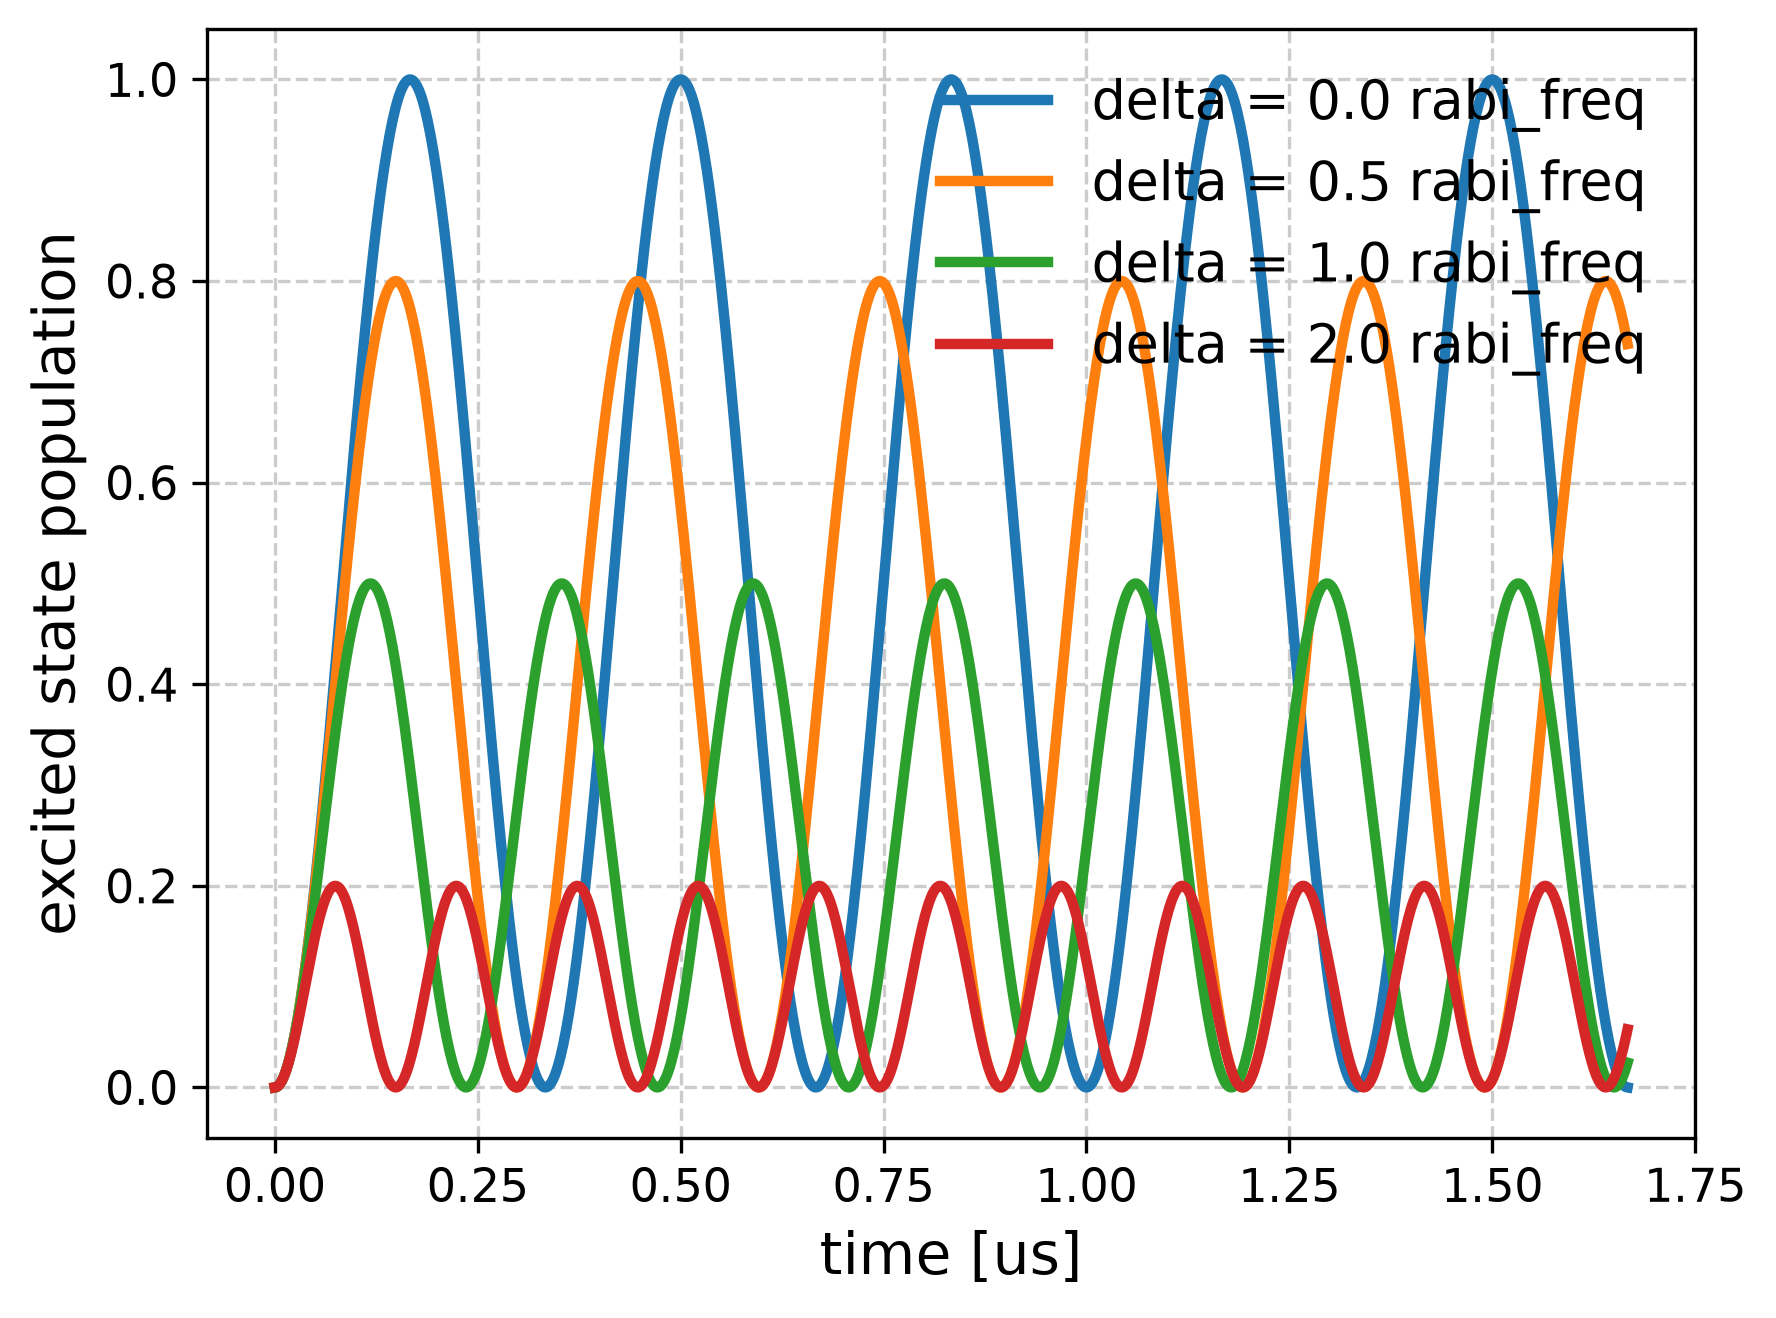

In [4]:
def plot_rabi_detunings(ax, t, rabi_freq, detuning_freqs):
    for detuning_freq in detuning_freqs:
        population = rabi_population(t, rabi_freq, detuning_freq)
        ax.plot(t, population, label=f"delta = {detuning_freq / rabi_freq:.1f} rabi_freq")
    ax.set_xlabel("time [us]")
    ax.set_ylabel("excited state population")
    ax.legend()


detuning_freqs = RABI_FREQ * np.array([0.0, 0.5, 1.0, 2.0])

fig, ax = plt.subplots(dpi=300)
plot_rabi_detunings(ax, t, RABI_FREQ, detuning_freqs)
plt.show()

## Effect of T2* dephasing

On resonance, dephasing damps the oscillation toward the steady-state value of 0.5 with time constant `T2*`.

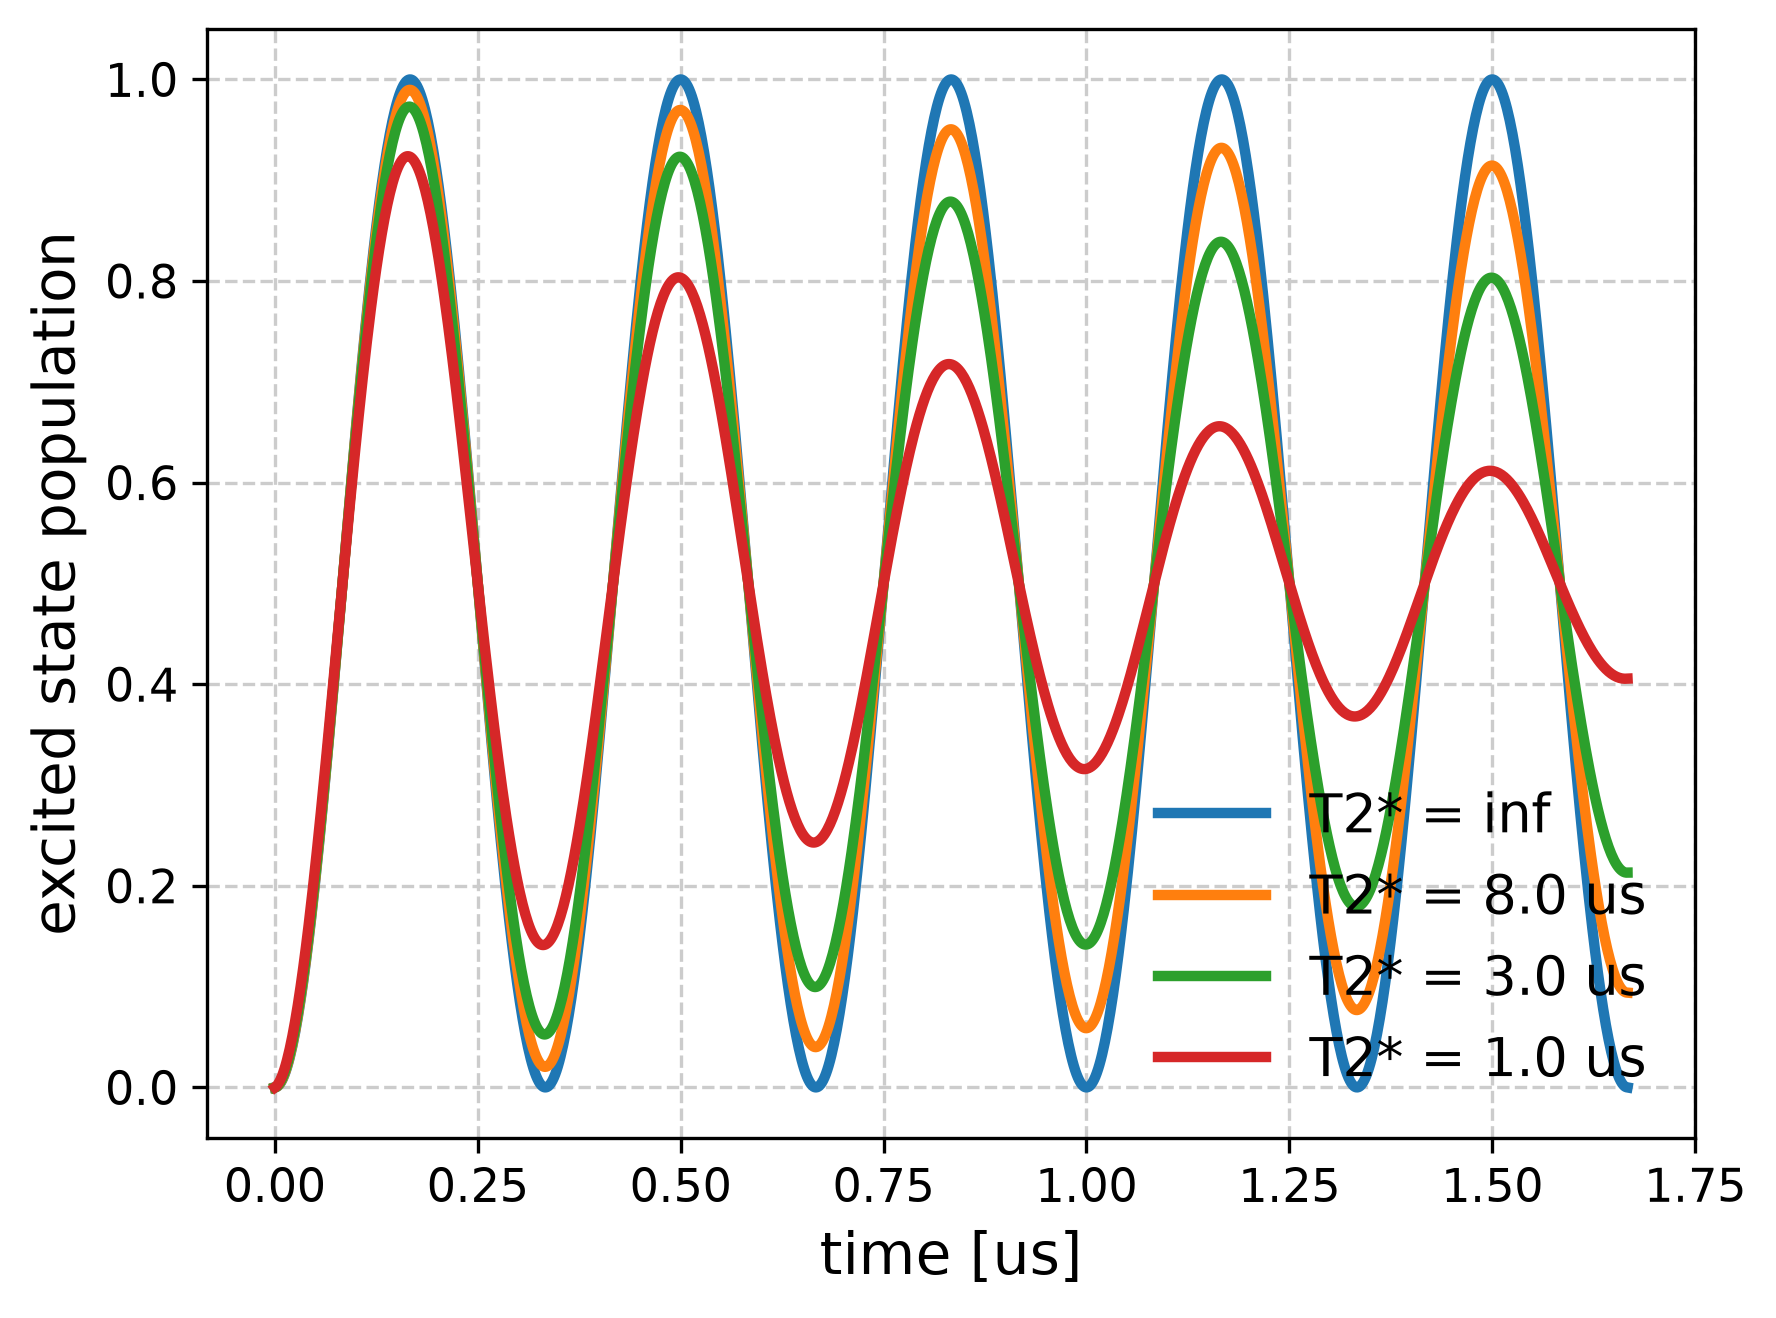

In [5]:
def plot_rabi_t2_stars(ax, t, rabi_freq, t2_stars):
    for t2_star in t2_stars:
        population = rabi_population(t, rabi_freq, t2_star=t2_star)
        label = f"T2* = {t2_star:.1f} us" if np.isfinite(t2_star) else "T2* = inf"
        ax.plot(t, population, label=label)
    ax.set_xlabel("time [us]")
    ax.set_ylabel("excited state population")
    ax.legend()


t_long = np.linspace(0, 10 * t_pi, 1000)
t2_stars = [np.inf, 8.0, 3.0, 1.0]

fig, ax = plt.subplots(dpi=300)
plot_rabi_t2_stars(ax, t_long, RABI_FREQ, t2_stars)
plt.show()